In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.utils import _initialize_pk
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels

jax.devices("gpu")

[cuda(id=0)]

In [101]:
# parts_per_dim = 64
parts_per_dim = 256
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

SNAPSHOT = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5"

In [102]:
def print_stats(array):
    print(f"mean = {array.mean():5e}")
    print(f"min = {array.min():5e}")
    print(f"max = {array.max():5e}")

# density rho

In [103]:
with h5py.File(SNAPSHOT, "r") as data:
    box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h
    
    gas_pos = data["PartType0/Coordinates"][:] / 1e3  # Mpc/h
    gas_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

    gas_mass = data["PartType0/Masses"][:] * 1e10  # Msun/h

    # density
    gas_rho = data["PartType0/Density"][:] * 1e10 * (1e3) ** 3  # (Msun/h)/(Mpc/h)^3

In [104]:
# match the per-particle values within PM with CAMELS
rho_gas_pm = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_mass)
gas_rho_pm = cic_read(rho_gas_pm, gas_pos)
gas_rho_pm *= (mesh_per_dim / box_size) ** 3  # (Msun/h)/(Mpc/h)^3

mean = 6.787831e+13
min = 2.448290e+08
max = 6.211368e+18

mean = 1.266499e+12
min = 1.212694e+09
max = 4.922335e+13


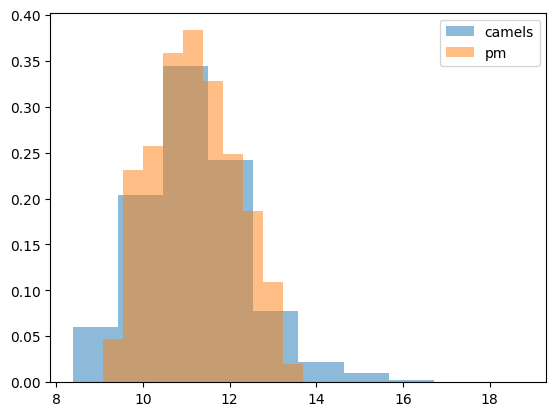

In [105]:
print_stats(gas_rho)
print("")
print_stats(gas_rho_pm)

plt.hist(np.log10(gas_rho), alpha=0.5, density=True, label="camels")
plt.hist(np.log10(gas_rho_pm), alpha=0.5, density=True, label="pm")
plt.legend()

# pressure P

In [106]:
with h5py.File(SNAPSHOT, "r") as data:
    box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h
    
    gas_pos = data["PartType0/Coordinates"][:] / 1e3  # Mpc/h
    gas_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

    gas_mass = data["PartType0/Masses"][:] * 1e10  # Msun/h

    # density
    gas_rho = data["PartType0/Density"][:] * 1e10 * (1e3) ** 3  # (Msun/h)/(Mpc/h)^3

    # pressure
    gamma = 5.0 / 3.0
    gas_U = data["PartType0/InternalEnergy"][:]  # (km/s)^2
    gas_P = (gamma - 1.0) * gas_U * gas_rho  # units are (Msun/h)*(km/s)^2/grid_pos^3

In [9]:
# match the per-particle values within PM with CAMELS
P_gas_pm = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, (gamma - 1.0) * gas_mass * gas_U)
gas_P_pm = cic_read(P_gas_pm, gas_pos)
gas_P_pm *= (mesh_per_dim / box_size) ** 3 # units are (Msun/h)*(km/s)^2/grid_pos^3

mean = 1.394123e+17
min = 7.215583e+09
max = 1.796200e+22

mean = 4.513335e+16
min = 7.475893e+09
max = 2.655324e+18


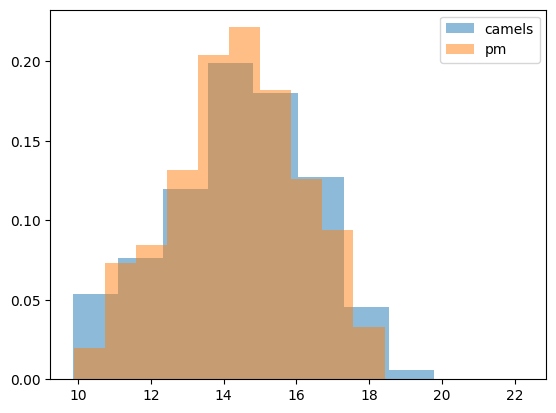

In [10]:
print_stats(gas_P)
print("")
print_stats(gas_P_pm)

plt.hist(np.log10(gas_P), alpha=0.5, density=True, label="camels")
plt.hist(np.log10(gas_P_pm), alpha=0.5, density=True, label="pm")
plt.legend()

# pressure 2

In [11]:
with h5py.File(SNAPSHOT, "r") as data:
    box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h
    
    gas_pos = data["PartType0/Coordinates"][:] / 1e3  # Mpc/h
    gas_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

    gas_mass = data["PartType0/Masses"][:] * 1e10  # Msun/h

    # density
    gas_rho = data["PartType0/Density"][:] * 1e10 * (1e3) ** 3  # (Msun/h)/(Mpc/h)^3

    # pressure
    gamma = 5.0 / 3.0
    gas_U = data["PartType0/InternalEnergy"][:]  # (km/s)^2
    gas_P = (gamma - 1.0) * gas_U * gas_rho  # units are (Msun/h)*(km/s)^2/grid_pos^3

In [12]:
# match the per-particle values within PM with CAMELS
P_gas_pm = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, (gamma - 1.0) * gas_mass * gas_U)
gas_P_pm = cic_read(P_gas_pm, gas_pos)
gas_P_pm *= (mesh_per_dim / box_size) ** 3 # units are (Msun/h)*(km/s)^2/grid_pos^3

mean = 1.394123e+17
min = 7.215583e+09
max = 1.796200e+22

mean = 4.513338e+16
min = 7.475893e+09
max = 2.655332e+18


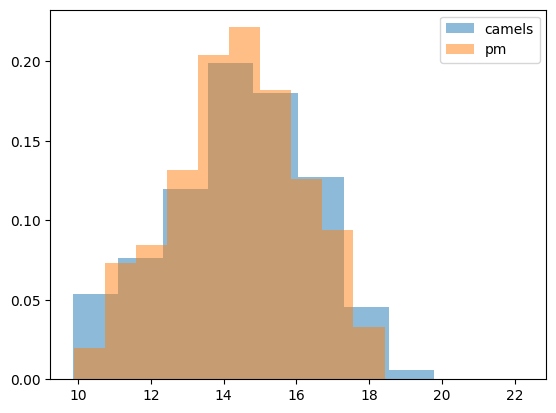

In [13]:
print_stats(gas_P)
print("")
print_stats(gas_P_pm)

plt.hist(np.log10(gas_P), alpha=0.5, density=True, label="camels")
plt.hist(np.log10(gas_P_pm), alpha=0.5, density=True, label="pm")
plt.legend()

# pressure 3

In [107]:
with h5py.File(SNAPSHOT, "r") as data:
    box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h
    
    gas_pos = data["PartType0/Coordinates"][:] / 1e3  # Mpc/h
    gas_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

    gas_mass = data["PartType0/Masses"][:] * 1e10  # Msun/h

    # density
    gas_rho = data["PartType0/Density"][:] * 1e10 * (1e3) ** 3  # (Msun/h)/(Mpc/h)^3

    # pressure
    gamma = 5.0 / 3.0
    gas_U = data["PartType0/InternalEnergy"][:]  # (km/s)^2
    gas_P = (gamma - 1.0) * gas_U * gas_rho  # units are (Msun/h)*(km/s)^2/grid_pos^3

In [108]:
# match the per-particle values within PM with CAMELS
rho_gas_pm = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_mass)
gas_rho_pm = cic_read(rho_gas_pm, gas_pos)  # dm_mass/(Mpc/h)^3
gas_rho_pm *= (mesh_per_dim / box_size) ** 3  # dm_mass/pm_len

P_gas_pm = (gamma - 1.0) * gas_U * gas_rho_pm

mean = 1.394123e+17
min = 7.215583e+09
max = 1.796200e+22

mean = 4.513338e+16
min = 7.475893e+09
max = 2.655332e+18


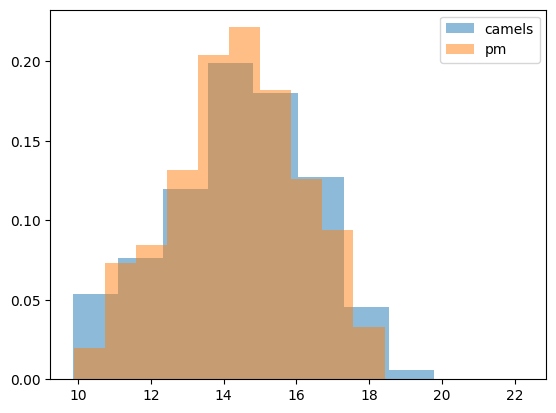

In [109]:
print_stats(gas_P)
print("")
print_stats(gas_P_pm)

plt.hist(np.log10(gas_P), alpha=0.5, density=True, label="camels")
plt.hist(np.log10(gas_P_pm), alpha=0.5, density=True, label="pm")
plt.legend()

# mass

In [14]:
SNAPSHOT = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_090.hdf5"
with h5py.File(SNAPSHOT, "r") as data:
    nbody_dm_mass = data["Header"].attrs["MassTable"][1] * 1e10  #  Msun/h

SNAPSHOT = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5"
with h5py.File(SNAPSHOT, "r") as data:
    hydro_dm_mass = data["Header"].attrs["MassTable"][1] * 1e10  #  Msun/h
    hydro_gas_mass = data["PartType0/Masses"][:] * 1e10

In [15]:
Omega_c = 0.3 - 0.049
Omega_b = 0.049

In [16]:
hpm_dm_mass = Omega_c / (Omega_c + Omega_b)
hpm_gas_mass = Omega_b / (Omega_c + Omega_b)

In [17]:
(jnp.mean(hydro_gas_mass) + hydro_dm_mass) / nbody_dm_mass

Array(1.0064774, dtype=float32)

In [18]:
hpm_gas_mass

0.16333333333333336

In [19]:
hydro_dm_mass/nbody_dm_mass

0.8366666666666667

In [20]:
Omega_c/(Omega_c + Omega_b)

0.8366666666666667

In [21]:
jnp.mean(hydro_gas_mass) / hydro_dm_mass

Array(0.20296097, dtype=float32)

In [22]:
Omega_b / Omega_c

0.1952191235059761

In [23]:
nbody_dm_mass

77546567.06246458

In [24]:
hpm_dm_mass + hpm_gas_mass

1.0

In [25]:
# parts_per_dim = 64
# mesh_per_dim = parts_per_dim
# mesh_shape = [mesh_per_dim] * 3

# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# # SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
# # SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2"

# out_dict = camels.load_CV_snapshots(
#     SIM,
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=range(1, 33+4, 8),
#     return_hydro=True,
# )

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 5/5 [00:53<00:00, 10.64s/it]


In [26]:
out_dict["dm_masss"]

[]

In [27]:
jnp.mean(out_dict["gas_masss"])

Array(0.16539729, dtype=float32)

# P comparison

In [96]:
with h5py.File(SNAPSHOT, "r") as data:
    box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h
    scale_factor = data["Header"].attrs["Time"]
    masses = data["Header"].attrs["MassTable"] * 1e10
    
    gas_pos = data["PartType0/Coordinates"][:] / 1e3  # Mpc/h
    gas_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates pm_len

    gas_vel = data["PartType0/Velocities"][:]  # peculiar velocities in km/s
    gas_vel *= mesh_per_dim * scale_factor / (box_size * 100)  # pm_vel (scale for peculiar, 100 for Hubble
    # NOTE this mysterious factor seems to be included in readgadget.read_block
    gas_vel *= np.sqrt(scale_factor)

    gas_mass = data["PartType0/Masses"][:] * 1e10  # Msun/h
    gas_mass /= (masses[1] + jnp.mean(gas_mass))  # dm_mass per particle

    # density
    rho_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_mass)
    gas_rho = cic_read(rho_gas, gas_pos)  # dm_mass/(Mpc/h)^3
    gas_rho *= (mesh_per_dim / box_size) ** 3  # dm_mass/pm_len

    # internal energy
    gas_U = data["PartType0/InternalEnergy"][:]  # (km/s)^2
    gas_U *= (mesh_per_dim * scale_factor / (box_size * 100)) ** 2  # rescale like the velocity, pm_vel^2
    # NOTE same mysterious factor as for the velocity
    gas_U *= scale_factor

    # pressure
    gamma = 5.0 / 3.0

    # the rho factor is implicitly included in the cic_paint
    P_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, (gamma - 1.0) * gas_U * gas_mass)
    gas_P_1 = cic_read(P_gas, gas_pos)
    gas_P_1 *= (mesh_per_dim / box_size) ** 3  #  dm_mass*pm_vel^2/dm_pos^3

    gas_P_2 = (gamma - 1.0) * gas_U * gas_rho
    # gas_P_2 *= (mesh_per_dim / box_size) ** 3


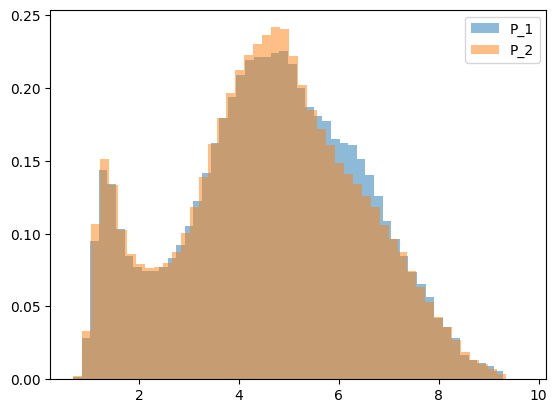

In [97]:
plt.hist(np.log10(gas_P_1), alpha=0.5, density=True, label="P_1", bins=50)
plt.hist(np.log10(gas_P_2), alpha=0.5, density=True, label="P_2", bins=50)
plt.legend()

In [87]:
N_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, 1)
gas_N = cic_read(N_gas, gas_pos)
gas_P_1 = gas_U * gas_N

P_2_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_U)
gas_P_2 = cic_read(P_2_gas, gas_pos)

(64, 64, 64)

In [71]:
gas_N.shape

(15695635,)

In [60]:
gas_P_1

Array([1.6224862e+07, 1.6393525e+07, 1.6592593e+07, ..., 2.0540884e+02,
       2.5054688e+01, 7.3964875e+04], dtype=float32)

In [61]:
gas_P_2

Array([2.76965568e+08, 3.13210432e+08, 3.96010688e+08, ...,
       1.52256738e+03, 5.43308472e+02, 1.01275556e+06], dtype=float32)

In [29]:
P_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_U * gas_mass)
gas_P_1 = cic_read(P_gas, gas_pos)

gas_P_2 = gas_U * gas_rho


In [32]:
rho_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_mass)
gas_rho = cic_read(rho_gas, gas_pos)

In [33]:
gas_rho

Array([10301.227  , 10386.827  , 10491.42   , ...,    26.29422,
          19.49111,   692.9091 ], dtype=float32)

In [98]:
(64 / 25) ** 3

16.777216000000003

In [34]:
# the rho factor is implicitly included in the cic_paint
P_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, gas_mass)
gas_P_1 = cic_read(P_gas, gas_pos)

gas_P_2 = gas_rho

In [35]:
gas_P_1

Array([10301.227   , 10386.827   , 10491.419   , ...,    26.2942  ,
          19.491108,   692.9084  ], dtype=float32)

In [36]:
gas_P_2

Array([10301.227  , 10386.827  , 10491.42   , ...,    26.29422,
          19.49111,   692.9091 ], dtype=float32)

In [37]:
gas_P_1/gas_P_2

Array([1.        , 1.        , 0.99999994, ..., 0.9999993 , 0.99999994,
       0.999999  ], dtype=float32)

# factors

In [38]:
mesh_per_dim = 64
scale_factor = 1
box_size = 25

np.log10((mesh_per_dim * scale_factor / (box_size * 100)) ** 2)

-3.183520069376301

In [39]:
0.049/(0.3 - 0.049)

0.1952191235059761

In [40]:
(64 / 25) ** 3

16.777216000000003

In [41]:
(0.049/(0.3 - 0.049))

0.1952191235059761

In [42]:
(mesh_per_dim / box_size) ** 3

16.777216000000003

In [43]:
N_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, 1)
gas_N = cic_read(N_gas, gas_pos)

N_gas_2 = cic_paint(N_gas, gas_pos, 1)
gas_N_2 = cic_read(N_gas_2, gas_pos)

In [44]:
gas_N

Array([49752.293   , 50166.367   , 50670.84    , ...,   125.883835,
          94.582726,  3478.3813  ], dtype=float32)

In [45]:
gas_N_2

Array([ 99499.8   , 100327.92  , 101336.86  , ...,    251.7677,
          189.1655,   6956.7515], dtype=float32)

In [46]:
gas_pos.shape

(15695635, 3)

In [47]:
jnp.sum(N_gas)

Array(15695624., dtype=float32)

In [48]:
gas_N.min()

Array(1.1889012, dtype=float32)

In [49]:
gas_N.max()

Array(64693.562, dtype=float32)

In [50]:
jnp.sum(gas_N)

Array(3.817545e+10, dtype=float32)

In [51]:
gas_N

Array([49752.293   , 50166.367   , 50670.84    , ...,   125.883835,
          94.582726,  3478.3813  ], dtype=float32)

In [52]:
gas_pos

array([[ 1.5761018, 44.72893  , 22.890202 ],
       [ 1.582804 , 44.739452 , 22.8944   ],
       [ 1.6109201, 44.74189  , 22.897942 ],
       ...,
       [43.709385 , 21.369238 , 51.855392 ],
       [58.85464  , 63.330692 , 61.551838 ],
       [11.006373 , 22.011309 , 38.241516 ]], dtype=float32)

In [53]:
import jax_cosmo as jc
import jax.numpy as jnp

In [54]:
cosmo = jc.Planck15(
    Omega_c=0.3 - 0.049,
    Omega_b=0.049,
    n_s=0.9624,
    h=0.6711,
    sigma8=0.8,
)

scales = jnp.linspace(0.1, 1, 10)

In [55]:
jc.background.Esqr(cosmo, scales)

Array([300.7      ,  38.2      ,  11.8111105,   5.3875   ,   3.1000001,
         2.088889 ,   1.5746354,   1.2859375,   1.1115227,   1.       ],      dtype=float32)